In [1]:
import os
import sys

parent_dir = os.path.abspath(os.path.join(os.path.dirname("inpire.py"), "../src"))
sys.path.append(parent_dir)

In [2]:
from inspire import InspireClassifier

import logging
import warnings
import numpy as np
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
warnings.simplefilter("ignore")

## Data

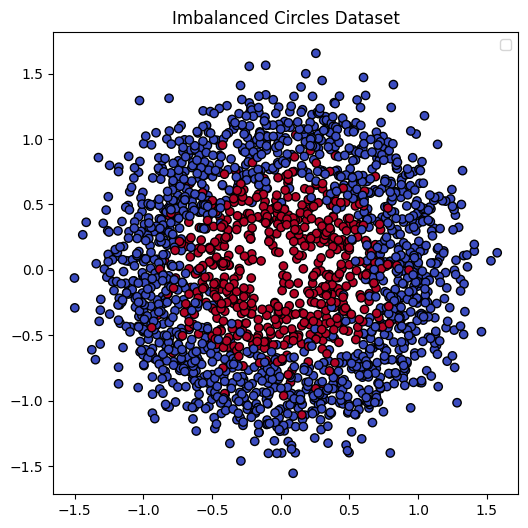

In [3]:
X, y = make_circles(n_samples=3000, factor=0.5, noise=0.2, random_state=42)

class_0 = X[y == 0]
class_1 = X[y == 1]

# determine disbalance ratio
imbalance_ratio = 0.4
n_class_1 = int(len(class_1) * imbalance_ratio)

X_imbalanced = np.vstack([class_0, class_1[:n_class_1]])
y_imbalanced = np.hstack([np.zeros(len(class_0)), np.ones(n_class_1)]).astype(int)

indices = np.random.permutation(len(y_imbalanced))
X_imbalanced = X_imbalanced[indices]
y_imbalanced = y_imbalanced[indices]

plt.figure(figsize=(6, 6))
plt.scatter(
    X_imbalanced[:, 0],
    X_imbalanced[:, 1],
    c=y_imbalanced,
    cmap="coolwarm",
    edgecolors="k",
)
plt.title("Imbalanced Circles Dataset")
plt.legend()
plt.show()

In [4]:
Counter(y_imbalanced)

Counter({np.int64(0): 1500, np.int64(1): 600})

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imbalanced, y_imbalanced, test_size=0.25, random_state=42, shuffle=True
)
X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, shuffle=True
)

In [6]:
print("train disbalance:", Counter(y_train))
print("test disbalance:", Counter(y_test))
print("val disbalance:", Counter(y_val))

train disbalance: Counter({np.int64(0): 1122, np.int64(1): 453})
test disbalance: Counter({np.int64(0): 199, np.int64(1): 63})
val disbalance: Counter({np.int64(0): 179, np.int64(1): 84})


## Training

In [7]:
logging.basicConfig(level=logging.DEBUG)

In [ ]:
model = InspireClassifier(
    n_estimators=50,
    base_estimator=DecisionTreeClassifier(
        max_depth=3,  # allows some pattern learning, but still weak
        min_samples_split=4,  # prevent very specific splits
        min_samples_leaf=5,  # reduce variance
        max_features=0.8,  # limit number of features considered at each split
        random_state=42,
    ),
    approximate_knn_=False,
    oversampling_ratio=0.5,
    val_to_train_neighbors=2,
    br_threshold=0.7,
    logging_level=logging.DEBUG,
    minority_class=1,
)

model.fit(
    X_train,
    y_train,
    X_val,
    y_val,
    save_history_=True,
    remove_cache_=False,
)

DEBUG:inspire:Starting fit process.
DEBUG:inspire:Using exact KNN.
2025-05-23 15:44:42,825 - inspire - INFO - Fitting KNN index... (0.01 seconds)
INFO:inspire:Fitting KNN index... (0.01 seconds)
DEBUG:inspire:Using cached training KNN results.
DEBUG:inspire:Removed 85 entries.
2025-05-23 15:44:42,826 - inspire - INFO - Removing outliers... (0.00 seconds)
INFO:inspire:Removing outliers... (0.00 seconds)
DEBUG:inspire:Using cached training KNN results.
DEBUG:inspire:Translating indices.
DEBUG:inspire:Translating indices.
2025-05-23 15:44:42,831 - inspire - INFO - Identifying border regions... (0.00 seconds)
INFO:inspire:Identifying border regions... (0.00 seconds)
DEBUG:inspire:Using exact KNN.
2025-05-23 15:44:42,834 - inspire - INFO - Fitting KNN index... (0.00 seconds)
INFO:inspire:Fitting KNN index... (0.00 seconds)
DEBUG:inspire:Using exact KNN.
2025-05-23 15:44:42,836 - inspire - INFO - Fitting KNN index for validation set... (0.00 seconds)
INFO:inspire:Fitting KNN index for valida

InspireClassifier(approximate_knn_=False,
                  base_estimator=DecisionTreeClassifier(max_depth=3,
                                                        max_features=0.8,
                                                        min_samples_leaf=5,
                                                        min_samples_split=4,
                                                        random_state=42),
                  br_threshold=0.7, cache_size=17, logging_level=10,
                  minority_class=1, n_estimators=50, oversampling_ratio=1,
                  val_to_train_neighbors=2)

## Results

In [10]:
print(f"Removed outliers: {np.sum(model.history[0]['removed_mask'])}")
print(f"Border indexes found: {np.sum(model.history[1]['border_mask'])}")

Removed outliers: 85
Border indexes found: 96


In [38]:
i = 3
br_mask = model.history[1]['border_mask']

while i < len(model.history):
    y_pred = model.history[i]["y_pred"]
    print(f"\nIteration {int((i - 1) / 2)}:")
    print(classification_report(y_val, y_pred))

    print(f"Problematic indexes found: {len(model.history[i]['minority_train_bp_indices'])}")
    print(
        f"Problematic overlap with border indexes: {np.sum(model.history[i]['minority_train_bp_mask'] & br_mask)}"
    )

    i += 2


Iteration 1:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       179
           1       0.86      0.75      0.80        84

    accuracy                           0.88       263
   macro avg       0.88      0.85      0.86       263
weighted avg       0.88      0.88      0.88       263

Problematic indexes found: 42
Problematic overlap with border indexes: 21

Iteration 2:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       179
           1       0.80      0.82      0.81        84

    accuracy                           0.88       263
   macro avg       0.86      0.86      0.86       263
weighted avg       0.88      0.88      0.88       263

Problematic indexes found: 30
Problematic overlap with border indexes: 15

Iteration 3:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       179
           1       0.74      0.89      0.81    

In [39]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.64      0.77       199
           1       0.45      0.94      0.61        63

    accuracy                           0.71       262
   macro avg       0.71      0.79      0.69       262
weighted avg       0.84      0.71      0.73       262



In [55]:
y_pred_train = model.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.97      0.61      0.75      1122
           1       0.49      0.95      0.65       453

    accuracy                           0.71      1575
   macro avg       0.73      0.78      0.70      1575
weighted avg       0.83      0.71      0.72      1575



In [ ]:
X_clean = X_train[~model.history[0]["removed_mask"]]
y_clean = y_train[~model.history[0]["removed_mask"]]

In [42]:
minority_mask = y_clean == 1

In [52]:
X_clean[minority_mask, 0].shape

(395,)

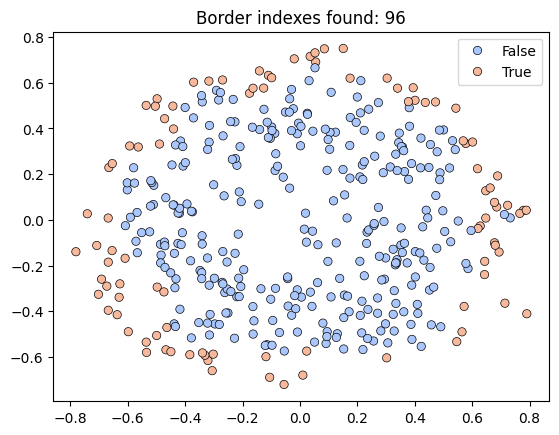

In [54]:
y_style = np.full(len(y_clean), "", dtype=object)
y_style[~minority_mask == 0] = "majority class"
y_style[minority_mask] = "minority class"

sns.scatterplot(
    x=X_clean[minority_mask, 0],
    y=X_clean[minority_mask, 1],
    hue=br_mask,
    palette="coolwarm",
    edgecolor="k",
)
plt.title(f"Border indexes found: {np.sum(model.history[1]['border_mask'])}")
plt.show()

KeyError: 'misclass_mask'

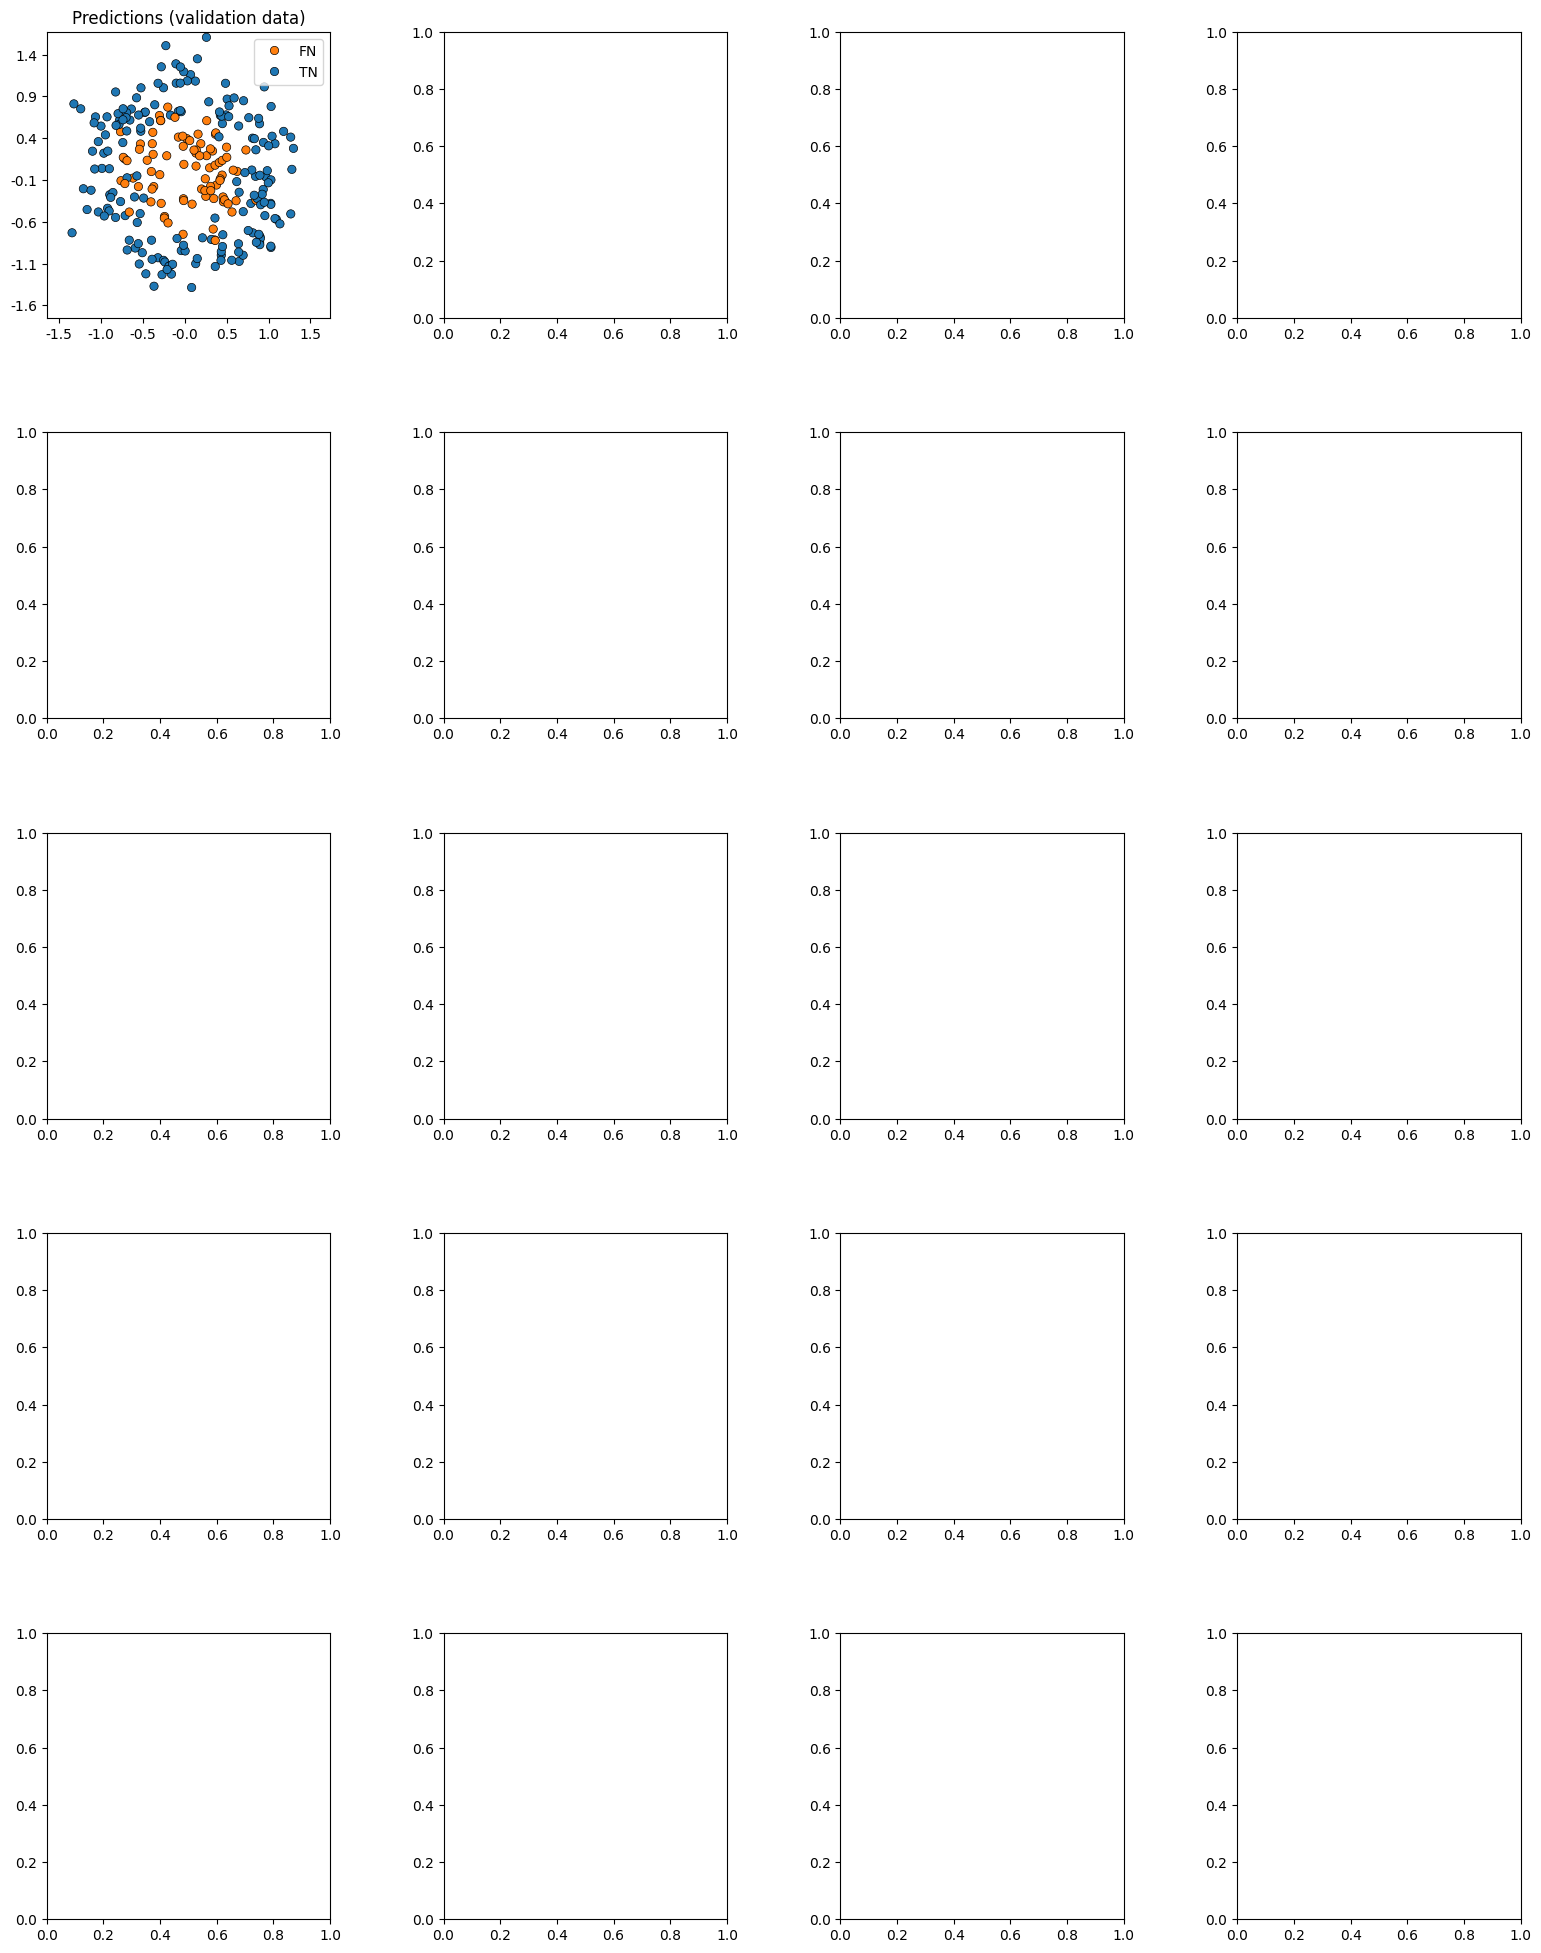

In [ ]:
majority_mask = y_clean == majority_class

gen = list(range(3, len(model.history), 10))

rows = len(gen)
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
fig.tight_layout(pad=3.0)
fig.subplots_adjust(wspace=0.4, hspace=0.4)

for j, i in enumerate(gen):
    y_style_val = np.full(len(y_val), "", dtype=object)
    y_style_val[(model.history[i]["y_pred"] == y_val) & (y_val == 1)] = "TP"
    y_style_val[(model.history[i]["y_pred"] == y_val) & (y_val == 0)] = "TN"
    y_style_val[(model.history[i]["y_pred"] != y_val) & (y_val == 1)] = "FN"
    y_style_val[(model.history[i]["y_pred"] != y_val) & (y_val == 0)] = "FP"

    sns.scatterplot(
        x=X_val[:, 0],
        y=X_val[:, 1],
        hue=y_style_val,
        palette={
            "TP": "#2ca02c",  # green
            "TN": "#1f77b4",  # blue
            "FP": "#d62728",  # red
            "FN": "#ff7f0e",  # orange
        },
        edgecolor="k",
        ax=axs[j, 0],
        legend="full",
    )

    axs[j, 0].set_xticks(np.arange(X_clean[:, 0].min(), X_clean[:, 0].max(), 0.5))
    axs[j, 0].set_yticks(np.arange(X_clean[:, 1].min(), X_clean[:, 1].max(), 0.5))
    axs[j, 0].set_xticklabels([f"{tick:.1f}" for tick in axs[j, 0].get_xticks()])
    axs[j, 0].set_yticklabels([f"{tick:.1f}" for tick in axs[j, 0].get_yticks()])
    axs[j, 0].set_xlim(
        X_clean[:, 0].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 0].max() + X_clean[:, 0].max() / 10,
    )
    axs[j, 0].set_ylim(
        X_clean[:, 1].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 1].max() + X_clean[:, 0].max() / 10,
    )
    axs[j, 0].legend(loc="upper right")
    axs[j, 0].set_title("Predictions (validation data)")

    mask_conf = model.history[i]["confidence_mask"]
    mask_miss = model.history[i]["misclass_mask"]
    val_bp_mask = model.history[i]["val_bp_mask"]
    mask = mask_conf | mask_miss

    hue = np.zeros(len(X_val), dtype=int)
    hue[mask_conf] += 1
    hue[mask_miss] -= 1

    sns.scatterplot(
        x=X_val[:, 0],
        y=X_val[:, 1],
        ax=axs[j, 1],
        alpha=0.1,
        color="blue",
        legend=False,
    )
    sns.scatterplot(
        x=X_val[mask, 0],
        y=X_val[mask, 1],
        hue=hue[mask],
        ax=axs[j, 1],
        alpha=1,
        palette={
            -1: "#d62728",  # red
            0: "#ff7f0e",  # orange
            1: "#2ca02c",  # green
        },
    )
    axs[j, 1].legend(
        handles=[
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label="miss",
                markerfacecolor="#d62728",
                markersize=10,
            ),
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label="both",
                markerfacecolor="#ff7f0e",
                markersize=10,
            ),
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label="low conf",
                markerfacecolor="#2ca02c",
                markersize=10,
            ),
        ],
        loc="upper right",
    )
    axs[j, 1].set_title("Bp analysis")

    palette = {
        True: "#90ee90",  # light green
        False: "#ffcccb",  # light red
    }
    sns.scatterplot(
        x=X_clean[majority_mask, 0],
        y=X_clean[majority_mask, 1],
        hue=model.history[i + 1]["bp_mask"][majority_mask],
        marker="*",
        palette=palette,
        edgecolor="k",
        ax=axs[j, 2],
        legend=False,
        alpha=0.5,
    )

    # Plot minority samples (higher alpha)
    sns.scatterplot(
        x=X_clean[~majority_mask, 0],
        y=X_clean[~majority_mask, 1],
        hue=model.history[i + 1]["bp_mask"][~majority_mask],
        palette=palette,
        edgecolor="k",
        ax=axs[j, 2],
        legend="full",  # avoid duplicate legends
        alpha=1,
    )

    axs[j, 2].legend(loc="upper right")
    axs[j, 2].set_title(
        f"Problematic indexes: {np.sum(model.history[i + 1]['bp_mask'])}"
    )
    axs[j, 2].set_xticks(np.arange(X_clean[:, 0].min(), X_clean[:, 0].max(), 0.5))
    axs[j, 2].set_yticks(np.arange(X_clean[:, 1].min(), X_clean[:, 1].max(), 0.5))
    axs[j, 2].set_xticklabels([f"{tick:.1f}" for tick in axs[j, 2].get_xticks()])
    axs[j, 2].set_yticklabels([f"{tick:.1f}" for tick in axs[j, 2].get_yticks()])
    axs[j, 2].set_xlim(
        X_clean[:, 0].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 0].max() + X_clean[:, 0].max() / 10,
    )
    axs[j, 2].set_ylim(
        X_clean[:, 1].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 1].max() + X_clean[:, 0].max() / 10,
    )

    sns.scatterplot(
        x=X_clean[majority_mask, 0],
        y=X_clean[majority_mask, 1],
        hue=(model.history[i + 1]["bp_mask"] & model.history[1]["border_mask"])[
            majority_mask
        ],
        marker="*",
        palette=palette,
        edgecolor="k",
        ax=axs[j, 3],
        alpha=0.5,
        legend=False,
    )

    # Plot minority samples with higher alpha
    sns.scatterplot(
        x=X_clean[~majority_mask, 0],
        y=X_clean[~majority_mask, 1],
        hue=(model.history[i + 1]["bp_mask"] & model.history[1]["border_mask"])[
            ~majority_mask
        ],
        palette=palette,
        edgecolor="k",
        ax=axs[j, 3],
        alpha=1,
        legend="full",  # avoid legend duplication
    )

    axs[j, 3].legend(loc="upper right")
    axs[j, 3].set_title(
        f"Problematic overlap with border indexes: {np.sum(model.history[i + 1]['bp_mask'] & model.history[1]['border_mask'])}"
    )
    axs[j, 3].set_xticks(np.arange(X_clean[:, 0].min(), X_clean[:, 0].max(), 0.5))
    axs[j, 3].set_yticks(np.arange(X_clean[:, 1].min(), X_clean[:, 1].max(), 0.5))
    axs[j, 3].set_xticklabels([f"{tick:.1f}" for tick in axs[j, 3].get_xticks()])
    axs[j, 3].set_yticklabels([f"{tick:.1f}" for tick in axs[j, 3].get_yticks()])
    axs[j, 3].set_xlim(
        X_clean[:, 0].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 0].max() + X_clean[:, 0].max() / 10,
    )
    axs[j, 3].set_ylim(
        X_clean[:, 1].min() - abs(X_clean[:, 0].min() / 10),
        X_clean[:, 1].max() + X_clean[:, 0].max() / 10,
    )

    if i > 3:
        print(
            f"Number of changed preds: {np.sum(model.history[i]['preds'] != model.history[i - 2]['preds'])}"
        )

plt.show()

## RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features=0.8,
    random_state=42,
)

In [ ]:
rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, max_features=0.8, min_samples_leaf=3,
                       min_samples_split=5, random_state=42)

In [ ]:
y_pred_rfc = rfc.predict(X_test)

print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       199
           1       0.90      0.75      0.82        63

    accuracy                           0.92       262
   macro avg       0.91      0.86      0.88       262
weighted avg       0.92      0.92      0.92       262

